## Setup and Imports

In [2]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import pathlib

#add model folder to path
sys.path.insert(0, str(pathlib.Path().resolve().parent.parent.parent))

from models.improved_gan_training import (
    BaselineGAN,
    LabelSmoothingGAN,
    FeatureMatchingGAN,
    ComparisonTrainer,
)

from models.basic_gan import create_generator, create_discriminator
print(" All imports successful!")


 All imports successful!


In [3]:
# Visualization helpers 
def plot_loss_comparison(results):
    """Plot loss curves for all three GAN variants."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    colors = {
        "Baseline": "navy",
        "Label Smoothing": "orange",
        "Feature Matching": "green",
    }

    # Plot discriminator losses
    ax = axes[0]
    for variant_name, losses in results.items():
        d_losses = losses["d_losses"]
        ax.plot(
            d_losses,
            label=variant_name,
            color=colors.get(variant_name, "blue"),
            alpha=0.8,
            linewidth=1.5,
        )
    ax.axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="Ideal (0.5)")
    ax.set_xlabel("Training Step", fontsize=11)
    ax.set_ylabel("Loss", fontsize=11)
    ax.set_title("Discriminator Loss Comparison", fontsize=12, fontweight="bold")
    ax.grid(alpha=0.3)
    ax.legend()

    # Plot generator losses
    ax = axes[1]
    for variant_name, losses in results.items():
        g_losses = losses["g_losses"]
        ax.plot(
            g_losses,
            label=variant_name,
            color=colors.get(variant_name, "blue"),
            alpha=0.8,
            linewidth=1.5,
        )
    ax.set_xlabel("Training Step", fontsize=11)
    ax.set_ylabel("Loss", fontsize=11)
    ax.set_title("Generator Loss Comparison", fontsize=12, fontweight="bold")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


def plot_stability_metrics(metrics):
    """Create 2x2 comparison visualization of training stability metrics."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    variants = list(metrics.keys())
    x_pos = np.arange(len(variants))
    width = 0.6
    colors_list = ["navy", "orange", "green"]

    # Subplot 1: Average D Loss
    ax = axes[0, 0]
    d_losses = [metrics[v]["avg_d_loss"] for v in variants]
    bars = ax.bar(x_pos, d_losses, width, color=colors_list[: len(variants)], alpha=0.8)
    ax.axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="Ideal (0.5)")
    ax.set_ylabel("Loss", fontsize=11)
    ax.set_title("Average D Loss (Last 100 Batches)", fontsize=11, fontweight="bold")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(variants, rotation=15, ha="right")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()

    # Subplot 2: D Loss Stability (Std Dev)
    ax = axes[0, 1]
    std_d_loss = [metrics[v]["std_d_loss"] for v in variants]
    bars = ax.bar(
        x_pos, std_d_loss, width, color=colors_list[: len(variants)], alpha=0.8
    )
    ax.set_ylabel("Std Dev", fontsize=11)
    ax.set_title("D Loss Stability (Lower = Better)", fontsize=11, fontweight="bold")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(variants, rotation=15, ha="right")
    ax.grid(True, axis="y", alpha=0.3)

    # Subplot 3: Average G Loss
    ax = axes[1, 0]
    g_losses = [metrics[v]["avg_g_loss"] for v in variants]
    bars = ax.bar(x_pos, g_losses, width, color=colors_list[: len(variants)], alpha=0.8)
    ax.set_ylabel("Loss", fontsize=11)
    ax.set_title("Average G Loss (Last 100 Batches)", fontsize=11, fontweight="bold")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(variants, rotation=15, ha="right")
    ax.grid(True, axis="y", alpha=0.3)

    # Subplot 4: D Loss Oscillation
    ax = axes[1, 1]
    d_osc = [metrics[v]["d_oscillation"] for v in variants]
    bars = ax.bar(x_pos, d_osc, width, color=colors_list[: len(variants)], alpha=0.8)
    ax.set_ylabel("Oscillation", fontsize=11)
    ax.set_title(
        "D Loss Oscillation (Lower = Smoother)", fontsize=11, fontweight="bold"
    )
    ax.set_xticks(x_pos)
    ax.set_xticklabels(variants, rotation=15, ha="right")
    ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


print(" Visualization helpers loaded")


 Visualization helpers loaded


## Part 1: Setup Device and Random Seed

In [4]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

torch.manual_seed(42)
print(f"Using device: {device}")


Using device: cpu


## Part 2: Load Fashion MNIST Dataset

In [5]:
# TODO: Create transforms for Fashion MNIST
# Transforms needed:
# 1. ToTensor() - convert images to tensors
# 2. Normalize((0.5,), (0.5,)) - normalize to [-1, 1] range

transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print("Loading Fashion MNIST dataset...")

# TODO: Load FashionMNIST dataset

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transforms
)

# TODO: Create DataLoader
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f" Dataset loaded")
print(f"  Total images: {len(train_dataset)}")
print(f"  Batch size: {batch_size}")
print(f"  Batches per epoch: {len(train_loader)}")


Loading Fashion MNIST dataset...


100%|██████████| 26.4M/26.4M [00:03<00:00, 6.78MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 39.4MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.43MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 29.9MB/s]

 Dataset loaded
  Total images: 60000
  Batch size: 64
  Batches per epoch: 938


## Part 3: Create Comparison Trainer

In [6]:
# TODO: Initialize ComparisonTrainer
# This will handle training all three variants

trainer = ComparisonTrainer()
print("Comparison trainer initialized")


Comparison trainer initialized


## Part 4: Train All Variants

 **WARNING**: This will take 15-20 minutes. Training three models × 50 epochs each.

In [7]:
# TODO: Call train_all_variants()
# This trains three GAN models: Baseline, Label Smoothing, Feature Matching
# Each trained for 50 epochs
#
# Parameters:
# - generator_class=create_generator
# - discriminator_class=create_discriminator
# - train_loader=train_loader
# - num_epochs=50
# - lr=0.0002
# - beta1=0.5

print("Training three GAN variants...")
print("(This will take ~15-20 minutes)\n")

results = trainer.train_all_variants(
    generator_class=create_generator,
    discriminator_class=create_discriminator,
    train_loader=train_loader,
    num_epochs=50,
    lr=0.0002,
    beta1=0.5,
)



Training three GAN variants...
(This will take ~15-20 minutes)

Training Baseline GAN (No Stabilization)...
Epoch 1/50 | D Loss: 0.2454 | G Loss: 2.8614
Epoch 10/50 | D Loss: 0.4257 | G Loss: 1.8239
Epoch 20/50 | D Loss: 0.4718 | G Loss: 1.5286
Epoch 30/50 | D Loss: 0.4684 | G Loss: 1.5074
Epoch 40/50 | D Loss: 0.4571 | G Loss: 1.5335
Epoch 50/50 | D Loss: 0.4427 | G Loss: 1.5689
 Training complete for Baseline (No Stabilization)


Training Label Smoothing GAN (0.9/0.1)...
Epoch 1/50 | D Loss: 0.4337 | G Loss: 1.9083
Epoch 10/50 | D Loss: 0.5452 | G Loss: 1.3519
Epoch 20/50 | D Loss: 0.5490 | G Loss: 1.2923
Epoch 30/50 | D Loss: 0.5435 | G Loss: 1.3062
Epoch 40/50 | D Loss: 0.5314 | G Loss: 1.3626
Epoch 50/50 | D Loss: 0.5208 | G Loss: 1.4214
 Training complete for Label Smoothing (0.9/0.1)


Training Feature Matching GAN...
Epoch 1/50 | D Loss: 0.2278 | G Loss: 2.8203
Epoch 10/50 | D Loss: 0.4157 | G Loss: 1.8384
Epoch 20/50 | D Loss: 0.4598 | G Loss: 1.5541
Epoch 30/50 | D Loss: 0.46

## Part 5: Visualize Loss Curves

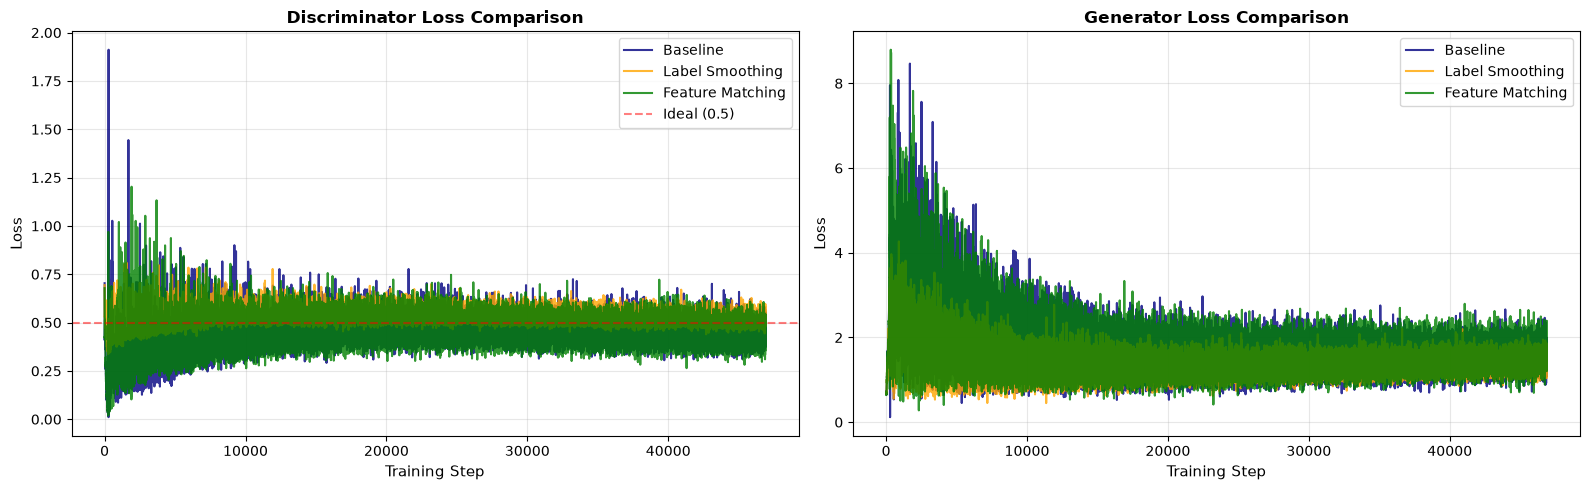

In [8]:
# TODO: Plot loss curves for all three variants using helper
plot_loss_comparison(results)

## Part 6: Compute Stability Metrics

In [ ]:
# TODO: Get stability metrics
# Call trainer.get_stability_metrics()
# This computes for each variant (last 100 batches):
#   - avg_d_loss: Average discriminator loss
#   - std_d_loss: Standard deviation (stability)
#   - avg_g_loss: Average generator loss
#   - std_g_loss: Generator stability
#   - d_oscillation: How much D loss bounces around
#   - g_oscillation: How much G loss bounces around

 metrics = None

# TODO: Print metrics for each variant
for variant_name, metric_dict in metrics.items():
    print(f"{variant_name}:")
    print(f"  Discriminator Loss:")
    print(f"    Average: {metric_dict['avg_d_loss']:.4f}")
    print(f"    Std Dev: {metric_dict['std_d_loss']:.4f}")
    print(f"    Oscillation: {metric_dict['d_oscillation']:.6f}")
    print(f"  Generator Loss:")
    print(f"    Average: {metric_dict['avg_g_loss']:.4f}")
    print(f"    Std Dev: {metric_dict['std_g_loss']:.4f}")
    print(f"    Oscillation: {metric_dict['g_oscillation']:.6f}\n")


## Part 7: Create Comparison Visualizations

In [ ]:
# TODO: Create 2×2 comparison visualization using helper
plot_stability_metrics(metrics)

## Part 8: Print Detailed Report

In [ ]:
# TODO: Call trainer.print_comparison_report()
# This will print:
# - Detailed metrics for each variant
# - Best variant for each metric
# - Analysis of training stability

trainer.print_comparison_report()


## Part 9: Analysis Questions

Answer these based on your experimental results:

In [ ]:
print("\nANALYSIS QUESTIONS - Answer based on your results:")
print("=" * 80)

print("\n1. Which technique produced the most stable training?")
print("   (Look for lowest std_d_loss across all batches)")
print("   Answer: ")
# TODO: Your answer here

print("\n2. Which technique kept D loss closest to the ideal 0.5?")
print("   (Ideal: discriminator confused but not useless)")
print("   Answer: ")
# TODO: Your answer here

print("\n3. Which technique showed the least oscillation?")
print("   (Smoother curves = better gradient flow)")
print("   Answer: ")
# TODO: Your answer here

print("\n4. Did any variant show signs of mode collapse?")
print("   (Signs: D loss → 0, G loss → ∞, visual artifacts in samples)")
print("   Answer: ")
# TODO: Your answer here

print("\n5. Rank the techniques 1-3 by overall performance:")
print("   (Consider stability, D loss balance, and practical usefulness)")
print("   Answer: ")
# TODO: Your answer here

print("\n6. Would you combine techniques or use one alone?")
print("   (Why or why not?)")
print("   Answer: ")
# TODO: Your answer here

print("\n" + "=" * 80)


## Summary

**What You Did:**
1. Trained three GAN variants with different stabilization techniques
2. Measured training stability using multiple metrics
3. Compared loss curves and identified differences
4. Analyzed which technique worked best
5. Made data-driven recommendations

**Key Takeaways:**
- Label Smoothing: Simple, quick win for stability
- Feature Matching: More complex, but better for sample quality
- Combining both: Often best, but requires more tuning
- Empirical testing: Always measure rather than guess!